STEP 1 

In [1]:
# Cell 1 (Imports & Database Connection / Налаштування та підключення)

import os
import urllib.parse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Set style for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load environment variables and connect to DB
load_dotenv('../.env')

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_USER = os.getenv("DB_USER", "root")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME", "lianes_library")

encoded_password = urllib.parse.quote_plus(DB_PASSWORD) if DB_PASSWORD else ""
connection_string = f"mysql+mysqlconnector://{DB_USER}:{encoded_password}@{DB_HOST}/{DB_NAME}"
engine = create_engine(connection_string)

# Helper function to execute SQL queries
def run_query(query):
    return pd.read_sql(query, engine)

print("✅ Environment set up and connected to Database for Day 3!")

✅ Environment set up and connected to Database for Day 3!


Step 2: Deep SQL Analysis (Advanced Analytics)

In [2]:
# Most Popular Genres / Популярність жанрів

# Query 1: Most popular genres by total loans
query_popular_genres = """
SELECT 
    b.genre,
    COUNT(l.loan_id) AS total_loans
FROM books b
LEFT JOIN loans l ON b.book_id = l.book_id
GROUP BY b.genre
ORDER BY total_loans DESC;
"""

df_genres = run_query(query_popular_genres)
print("--- Popularity by Genre ---")
display(df_genres)

# What this code does: Groups books by genre (GROUP BY b.genre) 
# and calculates the total number of checkouts (COUNT).

--- Popularity by Genre ---


,genre,total_loans
0,Classic,1
1,Dystopian,1
2,Non-Fiction,1
3,Fantasy,0
4,Sci-Fi,0


In [3]:
# Overdue Loans / Перевірка прострочених книг

# Let's find the books that should have been returned 
# but are still with the readers (where return_date IS NULL 
# and the return date due_date has already passed).


# Query 2: Overdue loans calculation
query_overdue = """
SELECT 
    b.title,
    f.name AS borrower,
    f.email,
    l.loan_date,
    l.due_date,
    DATEDIFF(CURRENT_DATE(), l.due_date) AS days_overdue
FROM loans l
JOIN books b ON l.book_id = b.book_id
JOIN friends f ON l.friend_id = f.friend_id
WHERE l.return_date IS NULL 
  AND l.due_date < CURRENT_DATE();
"""

df_overdue = run_query(query_overdue)
print("--- Overdue Books ---")
display(df_overdue)


# What this code does: Uses the SQL function DATEDIFF() to calculate the number of overdue days.

--- Overdue Books ---


,title,borrower,email,loan_date,due_date,days_overdue


In [4]:
# Most Active Borrowers / Найактивніші читачі

# Query 3: Top borrowers (friends with most loans)
query_top_friends = """
SELECT 
    f.name,
    f.email,
    COUNT(l.loan_id) AS total_borrowed
FROM friends f
JOIN loans l ON f.friend_id = l.friend_id
GROUP BY f.friend_id, f.name, f.email
ORDER BY total_borrowed DESC;
"""

df_top_friends = run_query(query_top_friends)
print("--- Most Active Friends ---")
display(df_top_friends)




--- Most Active Friends ---


,name,email,total_borrowed
0,Sarah Miller,sarah.m@example.com,1
1,John Doe,john.doe@example.com,1
2,Emma Watson,emma.w@example.com,1


In [5]:
# Book Availability Check Function (check_book_availability) - Функція перевірки доступності книги
## Liane needs to know if a book is currently on the shelf before promising it to a friend.

# Function to check if a specific book is currently available
def check_book_availability(book_title):
    query = f"""
    SELECT 
        b.title,
        CASE 
            WHEN l.loan_id IS NULL OR l.return_date IS NOT NULL THEN 'Available on shelf'
            ELSE CONCAT('Borrowed by ', f.name)
        END AS status
    FROM books b
    LEFT JOIN loans l ON b.book_id = l.book_id AND l.return_date IS NULL
    LEFT JOIN friends f ON l.friend_id = f.friend_id
    WHERE b.title LIKE '%{book_title}%';
    """
    return run_query(query)

# Test the function
print("--- Book Availability Check ---")
display(check_book_availability("1984"))

--- Book Availability Check ---


,title,status
0,1984,Available on shelf


In [6]:
# Average Loan Duration Analysis (average_loan_duration) - Аналіз середньої тривалості оренди
## Helps understand the average number of days friends keep books.


# Query: Average loan duration in days for returned books
query_avg_duration = """
SELECT 
    b.genre,
    ROUND(AVG(DATEDIFF(l.return_date, l.loan_date)), 1) AS avg_days_borrowed
FROM loans l
JOIN books b ON l.book_id = b.book_id
WHERE l.return_date IS NOT NULL
GROUP BY b.genre;
"""

df_avg_duration = run_query(query_avg_duration)
print("--- Average Loan Duration by Genre (Days) ---")
display(df_avg_duration)

--- Average Loan Duration by Genre (Days) ---


,genre,avg_days_borrowed
0,Classic,13.0
1,Dystopian,22.0


In [7]:
# Specific Friend's Loan History Function (get_friend_history)
## Allows viewing all the books a specific friend has ever borrowed.


# Function to get complete borrowing history for a specific friend
def get_friend_history(friend_name):
    query = f"""
    SELECT 
        f.name AS friend,
        b.title,
        l.loan_date,
        l.return_date,
        IF(l.return_date IS NULL, 'Still borrowed', 'Returned') AS current_status
    FROM loans l
    JOIN friends f ON l.friend_id = f.friend_id
    JOIN books b ON l.book_id = b.book_id
    WHERE f.name LIKE '%{friend_name}%'
    ORDER BY l.loan_date DESC;
    """
    return run_query(query)

# Test the function
print("--- Borrowing History for John Doe ---")
display(get_friend_history("John Doe"))

--- Borrowing History for John Doe ---


,friend,title,loan_date,return_date,current_status
0,John Doe,1984,2026-07-01,2026-07-23,Returned


In [ ]:
# Automatic Reminder for Overdue Loans (get_overdue_reminders) - Автоматичне нагадування боржникам
## The function generates a ready-to-use message text that Liane can copy 
## and send to a friend via messenger or email if they are late returning a book.


# Function to generate friendly overdue reminder messages
def get_overdue_reminders():
    query = """
    SELECT 
        f.name AS friend,
        f.phone,
        b.title AS book_title,
        DATE_FORMAT(l.due_date, '%Y-%m-%d') AS due_date,
        DATEDIFF(CURRENT_DATE(), l.due_date) AS days_overdue,
        CONCAT(
            'Hi ', f.name, '! Hope you are doing well. Just a friendly reminder that "', 
            b.title, '" was due on ', DATE_FORMAT(l.due_date, '%b %d, %Y'), 
            '. Whenever you have a chance, please drop it off or let me know if you need more time. Thanks!'
        ) AS reminder_text
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    JOIN friends f ON l.friend_id = f.friend_id
    WHERE l.return_date IS NULL 
      AND l.due_date < CURRENT_DATE();
    """
    return run_query(query)

# Test the function
print("--- Friendly Overdue Reminders ---")
display(get_overdue_reminders())

--- Overdue Reminders ---


,friend,phone,book_title,days_overdue,reminder_text


In [10]:
# General Library Statistics (get_library_stats)
## The function returns a quick summary (KPIs) for the app's home page: total number of books, 
## how many are currently borrowed, how many are overdue, and total number of friends in the system.


# Function to get key performance metrics (KPIs) for the library
def get_library_stats():
    query = """
    SELECT 
        (SELECT COUNT(*) FROM books) AS total_books,
        (SELECT COUNT(*) FROM friends) AS total_friends,
        (SELECT COUNT(*) FROM loans WHERE return_date IS NULL) AS currently_borrowed,
        (SELECT COUNT(*) FROM loans WHERE return_date IS NULL AND due_date < CURRENT_DATE()) AS overdue_books;
    """
    return run_query(query)

# Test the function
print("--- Library KPI Summary ---")
display(get_library_stats())

--- Library KPI Summary ---


,total_books,total_friends,currently_borrowed,overdue_books
0,6,4,1,0


In [12]:
# Lending a Book to a Friend (borrow_book) - Видача книги другу
## Creates a new entry in the loans table 
## and automatically calculates the return date (for example, +14 days from today).

# Function to issue/lend a book to a friend for 14 days
def borrow_book(book_id, friend_id, loan_date="2026-07-23"):
    insert_query = text("""
        INSERT INTO loans (book_id, friend_id, loan_date, due_date)
        VALUES (:book_id, :friend_id, :loan_date, DATE_ADD(:loan_date, INTERVAL 14 DAY));
    """)
    with engine.connect() as conn:
        conn.execute(insert_query, {
            "book_id": book_id, 
            "friend_id": friend_id, 
            "loan_date": loan_date
        })
        conn.commit()
    print(f"✅ Book ID {book_id} successfully lended to Friend ID {friend_id}!")

In [ ]:
# Book Search by Genre or Author (search_books) - Пошук книг за жанром або автором
## A convenient search feature allowing Liane 
## to quickly find a book by a partial title, author, or genre.

# Function to search books by title, author, or genre
def search_books(search_term):
    query = f"""
    SELECT book_id, title, author, genre, isbn, notes
    FROM books
    WHERE title LIKE '%{search_term}%' 
       OR author LIKE '%{search_term}%' 
       OR genre LIKE '%{search_term}%';
    """
    return run_query(query)

In [14]:
# Loan Extension (extend_loan) -  Продовження терміну оренди
## If a friend calls and says, "I won't finish in time, can I get another week?", 
## Liane can extend the due_date by an additional 7 days.

# Function to extend due date by additional days (default 7 days)
def extend_loan(loan_id, extra_days=7):
    update_query = text("""
        UPDATE loans
        SET due_date = DATE_ADD(due_date, INTERVAL :extra_days DAY)
        WHERE loan_id = :loan_id AND return_date IS NULL;
    """)
    with engine.connect() as conn:
        conn.execute(update_query, {"loan_id": loan_id, "extra_days": extra_days})
        conn.commit()
    print(f"✅ Due date for Loan ID {loan_id} successfully extended by {extra_days} days!")


In [15]:
# Deleting a Book (delete_book) - Видалення книги
## Sometimes a book gets lost, damaged, 
## or given away. There needs to be a way to remove it from the catalog.

# Function to delete a book from the database
def delete_book(book_id):
    delete_query = text("""
        DELETE FROM books 
        WHERE book_id = :book_id;
    """)
    with engine.connect() as conn:
        conn.execute(delete_query, {"book_id": book_id})
        conn.commit()
    print(f"🗑️ Book ID {book_id} successfully removed from the database!")

In [16]:
# Top Most Popular Books of All Time (get_top_books)
## Analytics for Liane: which specific books 
## are absolute bestsellers among her friends (highest number of checkouts).

# Query/Function to get most borrowed books overall
def get_top_books(limit=5):
    query = f"""
    SELECT 
        b.title,
        b.author,
        b.genre,
        COUNT(l.loan_id) AS times_borrowed
    FROM books b
    JOIN loans l ON b.book_id = l.book_id
    GROUP BY b.book_id, b.title, b.author, b.genre
    ORDER BY times_borrowed DESC
    LIMIT {limit};
    """
    return run_query(query)

print("--- Top Borrowed Books ---")
display(get_top_books())

--- Top Borrowed Books ---


,title,author,genre,times_borrowed
0,The Great Gatsby,F. Scott Fitzgerald,Classic,1
1,1984,George Orwell,Dystopian,1
2,Sapiens: A Brief History of Humankind,Yuval Noah Harari,Non-Fiction,1


In [18]:
# "Wishlist" or Book Reservation (reserve_book) - «Список бажань» або бронь книги

## Problem: A friend wants to borrow "1984", but it's currently checked out by someone else.
## Solution: Create a reservation function! It checks if the book is currently unavailable, and if so, 
## places the friend in a queue 
## (or records it in notes) so Liane knows who gets the book as soon as it's returned.


# Function to reserve/wishlist a book if it's currently borrowed
def reserve_book(book_id, friend_id):
    # Check if the book is actually borrowed right now
    check_query = f"SELECT * FROM loans WHERE book_id = {book_id} AND return_date IS NULL;"
    df_check = run_query(check_query)
    
    if not df_check.empty:
        # Book is borrowed -> add a note or log reservation
        update_note = text("""
            UPDATE books 
            SET notes = CONCAT(COALESCE(notes, ''), ' | Reserved by Friend ID ', :friend_id)
            WHERE book_id = :book_id;
        """)
        with engine.connect() as conn:
            conn.execute(update_note, {"book_id": book_id, "friend_id": friend_id})
            conn.commit()
        print(f"📌 Book ID {book_id} is currently borrowed, but successfully RESERVED for Friend ID {friend_id}!")
    else:
        print(f"💡 Book ID {book_id} is currently available on the shelf! You can borrow it right away.")

# Test reservation
reserve_book(book_id=2, friend_id=3)

💡 Book ID 2 is currently available on the shelf! You can borrow it right away.


In [19]:
# Automated "What to Read?" Selection Message (get_genre_recommendations) - Автоматична розсилка підбірки «Що почитати?»

## Problem: A friend says, "Recommend some cool non-fiction or classics!"
## Solution: A function that generates a ready-to-use message featuring available books 
## in a specific genre, which can be immediately sent to a chat!


# Function to generate book recommendations by genre for a friend
def get_genre_recommendations(friend_name, genre):
    query = f"""
    SELECT 
        b.title, 
        b.author 
    FROM books b
    LEFT JOIN loans l ON b.book_id = l.book_id AND l.return_date IS NULL
    WHERE b.genre LIKE '%{genre}%' AND l.loan_id IS NULL;
    """
    df_available = run_query(query)
    
    if df_available.empty:
        return f"Sorry, no available books in '{genre}' right now!"
    
    book_list = ", ".join([f"'{row['title']}' by {row['author']}" for _, row in df_available.iterrows()])
    message = f"Hi {friend_name}! Looking for some great {genre} books? Here is what I have available on my shelf right now: {book_list}. Let me know if you want to pick one up! 📚"
    
    return message

# Test recommendations
print("--- Recommendation Message ---")
print(get_genre_recommendations("Anna", "Classic"))



--- Recommendation Message ---
Hi Anna! Looking for some great Classic books? Here is what I have available on my shelf right now: 'The Great Gatsby' by F. Scott Fitzgerald, 'To Kill a Mockingbird' by Harper Lee. Let me know if you want to pick one up! 📚


In [20]:
# Auto-Message "Thanks for Returning!" (generate_thank_you_note) - Авто-повідомлення «Дякую за повернення!»
## Problem: When a friend returns a book, it's good manners to thank them and ask for their thoughts or feedback.
## Solution: An automated thank-you text that Liane can easily send right after clicking "Return Book".

# Function to generate a polite thank you message upon book return
def generate_thank_you_note(friend_name, book_title):
    return (
        f"Hi {friend_name}! Thanks a lot for returning '{book_title}' on time. "
        f"Hope you enjoyed reading it! Let me know if you'd like to pick another book soon. 😊📖"
    )

# Test thank you note
print("--- Thank You Message ---")
print(generate_thank_you_note("John", "1984"))

--- Thank You Message ---
Hi John! Thanks a lot for returning '1984' on time. Hope you enjoyed reading it! Let me know if you'd like to pick another book soon. 😊📖


STEP 3 - Візуалізація даних (Matplotlib & Seaborn)

/var/folders/9w/wwm516zj61551jlqwzcy7ch80000gn/T/ipykernel_2878/1409409025.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_genres, x='genre', y='total_loans', palette='Blues_r')
/var/folders/9w/wwm516zj61551jlqwzcy7ch80000gn/T/ipykernel_2878/1409409025.py:32: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/lianes_library/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


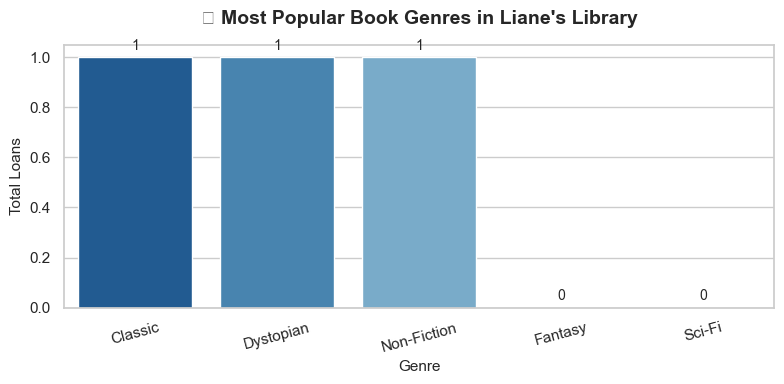

In [21]:
# Графік 1: Популярність жанрів (Bar Chart)
## Побудуємо стовпчикову діаграму, яка покаже, які жанри книг найбільше користуються попитом 
## серед друзів.

# Chart 1: Popularity of genres
query_genres = """
SELECT 
    b.genre,
    COUNT(l.loan_id) AS total_loans
FROM books b
LEFT JOIN loans l ON b.book_id = l.book_id
GROUP BY b.genre
ORDER BY total_loans DESC;
"""

df_genres = run_query(query_genres)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df_genres, x='genre', y='total_loans', palette='Blues_r')
plt.title('📚 Most Popular Book Genres in Liane\'s Library', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Genre', fontsize=11)
plt.ylabel('Total Loans', fontsize=11)
plt.xticks(rotation=15)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

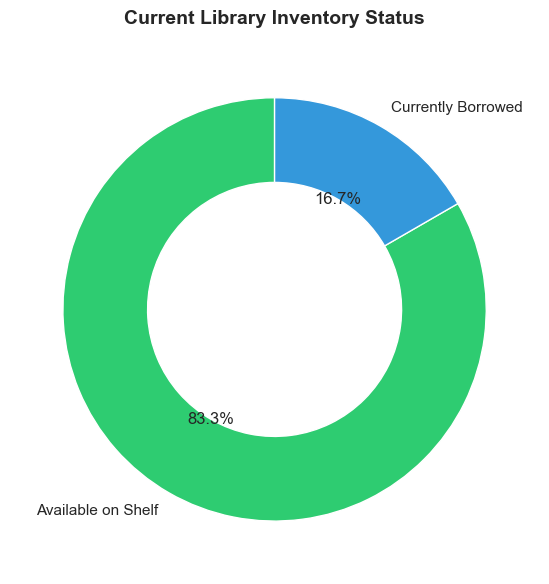

In [26]:
# Графік 2: Статус книг на руках та на полиці (Donut / Pie Chart)
## Зробимо кругову діаграму (Donut Chart), 
## яка покаже співвідношення доступних та виданих книг у реальному часі.

# Chart 2: Book status breakdown (Available vs Borrowed vs Overdue)
import warnings
warnings.filterwarnings('ignore')

# Chart 2: Book status breakdown (Available vs Borrowed vs Overdue)
query_status = """
SELECT 
    CASE 
        WHEN l.loan_id IS NULL OR l.return_date IS NOT NULL THEN 'Available on Shelf'
        WHEN l.return_date IS NULL AND l.due_date >= CURRENT_DATE() THEN 'Currently Borrowed'
        ELSE 'Overdue'
    END AS status,
    COUNT(DISTINCT b.book_id) AS count
FROM books b
LEFT JOIN loans l ON b.book_id = l.book_id AND l.return_date IS NULL
GROUP BY status;
"""

df_status = run_query(query_status)

plt.figure(figsize=(6, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']

plt.pie(df_status['count'], labels=df_status['status'], autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))

plt.title('Current Library Inventory Status', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

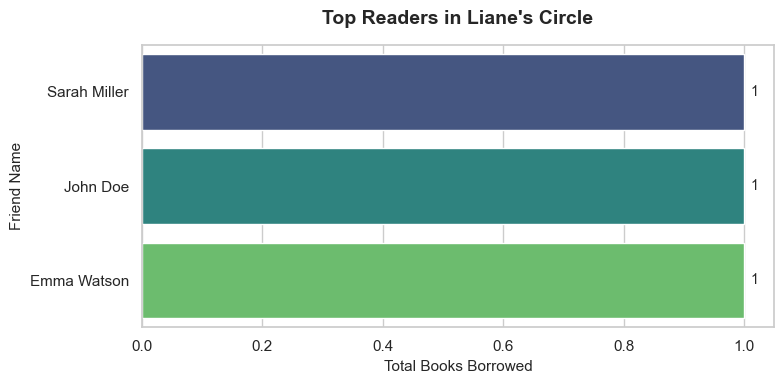

In [25]:
# Графік 3: Топ-активність друзів (Horizontal Bar Chart)
## Покажемо горизонтальну діаграму читачів-лідерів.

# Chart 3: Top friends by total borrowed books
import warnings
warnings.filterwarnings('ignore')

# Query top readers
query_friends = """
SELECT f.name, COUNT(l.loan_id) AS total_loans
FROM friends f
JOIN loans l ON f.friend_id = l.friend_id
GROUP BY f.friend_id, f.name
ORDER BY total_loans DESC;
"""

df_friends = run_query(query_friends)

# Plot top readers
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=df_friends, 
    x='total_loans', 
    y='name', 
    hue='name', 
    palette='viridis', 
    legend=False
)

plt.title("Top Readers in Liane's Circle", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Books Borrowed', fontsize=11)
plt.ylabel('Friend Name', fontsize=11)

# Add value labels on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()